# Earthquake Intensity Map of Venezuela

Earthquake Intensity Data was obtained from [USGS ShakeMap](https://earthquake.usgs.gov/) and was overlaid with shapefiles of Venezuela admin 2 (municipality) boundaries taken from [OCHA HDX](https://data.humdata.org/). This can be used as a baseline map upon which other indicators can be visualized.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
# Load earthquake intensity ShakeMap (Modified Mercalli Intensity)
mi = gpd.read_file("../../data/earthquake_intensity/shape/mi.shp")
mi_2 = gpd.read_file("../../data/earthquake_intensity/shape_7.2/mi.shp")

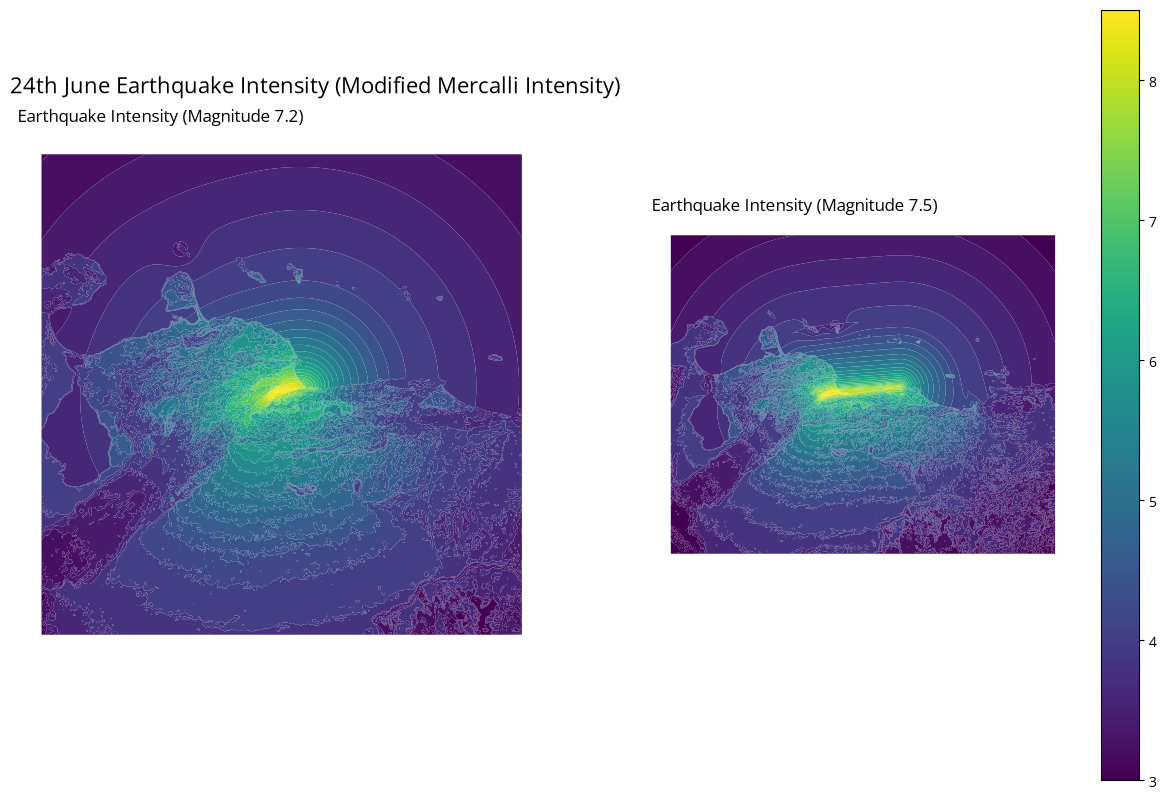

In [3]:
plt.rcParams["font.family"] = "Open Sans"

fig, ax = plt.subplots(1, 2, figsize=(15, 10))
mi_2.plot(column='PARAMVALUE', legend=False, ax=ax[0], vmin=3, vmax=8.5)
ax[0].set_title("Earthquake Intensity (Magnitude 7.2)", loc="left")
mi.plot(column='PARAMVALUE', legend=True, ax=ax[1], vmin=3, vmax=8.5)
ax[1].set_title("Earthquake Intensity (Magnitude 7.5)", loc="left")
ax[0].set_axis_off()
ax[1].set_axis_off()
fig.suptitle("24th June Earthquake Intensity (Modified Mercalli Intensity)", fontsize=16, x=0.12,y=0.82, ha="left");

In [4]:
# Load Venezuela admin 2 (municipality) boundaries
ven_adm2 = gpd.read_file(
    "../../data/boundaries/ven_admin_boundaries.geojson/ven_admin2.geojson"
)
ven_adm3 = gpd.read_file(
    "../../data/boundaries/ven_admin_boundaries.geojson/ven_admin3.geojson"
)

### Earthquake Magnitude vs. Modified Mercalli Intensity (MMI) Reference

| Earthquake Magnitude (M) [[1](https://www.battlbox.com/blogs/outdoors/what-is-the-earthquake-scale) [2](https://www.ebsco.com/research-starters/earth-and-atmospheric-sciences/earthquake-magnitudes-and-intensities) [3](https://geo.libretexts.org/Bookshelves/Geology/Fundamentals_of_Geology_(Schulte)/08%3A_Earthquakes/8.09%3A_Magnitude_vs._Intensity) [4](https://www.nrc.gov/docs/ML1821/ML18214A882.pdf)] | Typical Maximum MMI Value | Felt Effects |
|:---|:---:|:---|
| **1.0 – 3.0** | **I** | Usually not felt by anyone. |
| **3.0 – 3.9** | **II – III** | Felt noticeably indoors; similar vibration to a passing truck. |
| **4.0 – 4.9** | **IV – V** | Dishes rattle, walls crack, waking many people. |
| **5.0 – 5.9** | **VI – VII** | Felt by everyone; slight to moderate structural damage occurs. |
| **6.0 – 6.9** | **VII – IX** | Damage ranges from considerable to heavy; chimneys may fall. |
| **7.0+** | **VIII or higher** | Severe destruction; foundations are damaged and bridges compromised. |

In [5]:
# Spatial join: assign each intensity polygon to municipality + state
gdf_adm3_mi = mi[["PARAMVALUE", "geometry"]].sjoin(
    ven_adm3[["adm3_name", "adm2_name", "adm1_name", "geometry"]]
)

gdf_adm3_mi2 = mi_2[["PARAMVALUE", "geometry"]].sjoin(
    ven_adm3[["adm3_name", "adm2_name", "adm1_name", "geometry"]]
)

In [6]:
# Compute max intensity per municipality
df_mi = (
    gdf_adm3_mi.groupby(["adm3_name", "adm2_name", "adm1_name"])
    .agg({"PARAMVALUE":'max'})
    .reset_index()[["adm3_name", "adm2_name", "adm1_name", "PARAMVALUE"]]
    .sort_values(by="PARAMVALUE", ascending=False)
)
df_mi.rename(columns={"PARAMVALUE": "max_intensity"}, inplace=True)

df_mi2 = (
    gdf_adm3_mi2.groupby(["adm3_name", "adm2_name", "adm1_name"])
    .agg({"PARAMVALUE":'max'})
    .reset_index()[["adm3_name", "adm2_name", "adm1_name", "PARAMVALUE"]]
    .sort_values(by="PARAMVALUE", ascending=False)
)
df_mi2.rename(columns={"PARAMVALUE": "max_intensity"}, inplace=True)

In [7]:
df = df_mi.merge(df_mi2, on=["adm3_name", "adm2_name", "adm1_name"],how='outer', suffixes=("_7.5", "_7.2"))
df.shape

(1074, 5)

In [8]:
# Merge intensity back onto full admin2 boundary (fill 0 where no data)
df_all = ven_adm3[["adm3_name", "adm2_name", "adm1_name"]].merge(
    df, on=["adm3_name", "adm2_name", "adm1_name"], how="left"
)
df_all = df_all.groupby(["adm3_name", "adm2_name", "adm1_name"]).mean().reset_index().fillna(0)

In [9]:
# Save to CSV
df_all[["adm3_name", "adm2_name", "adm1_name", "max_intensity_7.5", "max_intensity_7.2"]].to_csv(
    "../../data/earthquake_intensity/venezuela_adm3_earthquake_intensity.csv",
    index=False,
)

In [10]:
# Merge intensity data back onto geodataframe for plotting
gdf = ven_adm3.merge(df_all, on=["adm3_name", "adm2_name", "adm1_name"])

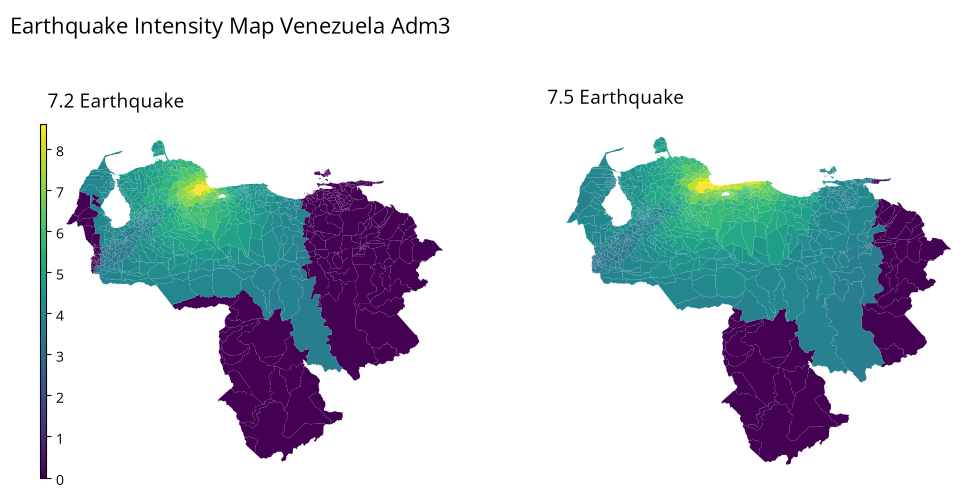

In [11]:
plt.rcParams["font.family"] = "Open Sans"

fig, ax = plt.subplots(1,2,figsize=(12, 6))

gdf.plot(column="max_intensity_7.5", cmap="viridis", ax=ax[1])
gdf.plot(column="max_intensity_7.2", cmap="viridis", ax=ax[0])

for i in [0,1]:
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["bottom"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
    ax[i].spines["left"].set_visible(False)

    ax[i].set_xticks([])
    ax[i].set_yticks([])

ax[1].set_title("7.5 Earthquake", fontsize=14, pad=12, loc="left")
ax[0].set_title("7.2 Earthquake", fontsize=14, pad=12, loc="left")

vmin = gdf["max_intensity_7.5"].min()
vmax = gdf["max_intensity_7.5"].max()

sm = plt.cm.ScalarMappable(
    cmap="viridis", norm=plt.Normalize(vmin=vmin, vmax=vmax)
)

divider = make_axes_locatable(ax[0])
divider_kwargs = dict(position="left", size="1.5%", pad=0)
fig.colorbar(
    sm,
    cax=divider.append_axes(**divider_kwargs),
)

fig.suptitle("Earthquake Intensity Map Venezuela Adm3", fontsize=16, x=0.1, ha="left");

## People living in areas impacted

In [44]:
import rasterio
import numpy as np
from shapely.geometry import Point

tif_path = "../../data/population/ven_pop_2026_CN_100m_R2025A_v1.tif"

with rasterio.open(tif_path) as src:
    data = src.read(1)                  # first band = population count
    nodata = src.nodata
    transform = src.transform
    crs = src.crs

# Build (row, col) indices for all valid (non-nodata, non-zero) pixels
rows, cols = np.where((data != nodata) & (data > 0))

# Convert pixel indices to geographic coordinates (pixel centre)
xs, ys = rasterio.transform.xy(transform, rows, cols)

pop = gpd.GeoDataFrame(
    {"population": data[rows, cols]},
    geometry=[Point(x, y) for x, y in zip(xs, ys)],
    crs=crs,
).to_crs("EPSG:4326")

pop.head()

/var/folders/gs/_227cnyd0pq1fr817_0jbcyw0000gp/T/ipykernel_48825/1405948110.py:8: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data = src.read(1)                  # first band = population count


,population,geometry
0,0.032928,POINT (-70.90292 12.36208)
1,0.093611,POINT (-70.90208 12.36208)
2,0.054641,POINT (-70.90125 12.36208)
3,0.105052,POINT (-70.90208 12.36125)
4,0.221663,POINT (-70.90208 12.36042)


In [45]:
import math

def lat_lon_to_quadkey(lat: float, lon: float, zoom: int) -> str:
    """
    Converts geographic coordinates (latitude, longitude) into a QuadKey
    string for a given zoom level using the Web Mercator projection.
    """

    # 2. Convert Lat/Lon to Pixel coordinates at the specified zoom level
    # 256 is the standard tile width/height in pixels
    map_size = 256 << zoom  # Equivalent to 256 * (2^zoom)
    
    x = (lon + 180) / 360
    sin_lat = math.sin(lat * math.pi / 180)
    y = 0.5 - math.log((1 + sin_lat) / (1 - sin_lat)) / (4 * math.pi)
    
    pixel_x = int(max(min(x * map_size + 0.5, map_size - 1), 0))
    pixel_y = int(max(min(y * map_size + 0.5, map_size - 1), 0))

    # 3. Convert Pixel coordinates to Tile coordinates
    tile_x = pixel_x // 256
    tile_y = pixel_y // 256

    # 4. Convert Tile coordinates to an interleaved base-4 QuadKey string
    quadkey = []
    for i in range(zoom, 0, -1):
        digit = 0
        mask = 1 << (i - 1)
        if (tile_x & mask) != 0:
            digit += 1
        if (tile_y & mask) != 0:
            digit += 2
        quadkey.append(str(digit))

    return "".join(quadkey)

In [46]:
def quadkey_to_shapely_polygon(quadkey: str) -> Polygon:
    """
    Decodes a QuadKey string and returns its bounding box as a Shapely Polygon.
    Coordinates are outputted in geographic format (longitude, latitude).
    """
    # 1. Decode QuadKey to Tile X, Tile Y, and Zoom level
    tile_x = 0
    tile_y = 0
    zoom = len(quadkey)
    
    for i in range(zoom, 0, -1):
        mask = 1 << (i - 1)
        digit = quadkey[zoom - i]
        
        if digit == '1':
            tile_x |= mask
        elif digit == '2':
            tile_y |= mask
        elif digit == '3':
            tile_x |= mask
            tile_y |= mask
        elif digit != '0':
            raise ValueError(f"Invalid QuadKey digit: {digit}")

    # 2. Internal helper function to convert Tile X/Y to Lat/Lon
    def tile_to_lat_lon(tx: int, ty: int, z: int):
        map_size = 256 << z
        x = (max(min(tx * 256, map_size - 1), 0) / map_size) - 0.5
        y = 0.5 - (max(min(ty * 256, map_size - 1), 0) / map_size)
        
        lon = 360 * x
        lat = 90 - 360 * math.atan(math.exp(-y * 2 * math.pi)) / math.pi
        return lat, lon

    # 3. Get bounds for the corners
    north, west = tile_to_lat_lon(tile_x, tile_y, zoom)
    south, east = tile_to_lat_lon(tile_x + 1, tile_y + 1, zoom)
    
    # 4. Define the 4 corners in clockwise/counter-clockwise order (Lon, Lat)
    # Shapely automatically closes the polygon loop if the last coordinate matches the first
    corners = [
        (west, north),  # Top-Left
        (east, north),  # Top-Right
        (east, south),  # Bottom-Right
        (west, south)   # Bottom-Left
    ]
    
    return Polygon(corners)

In [47]:
pop['quadkey'] = pop['geometry'].apply(lambda geom: lat_lon_to_quadkey(geom.y, geom.x, zoom=19))

In [16]:
pop_quad18 = pop.groupby('quadkey')['population'].sum().reset_index()
#pop_quad19

In [17]:
from shapely import Polygon
pop_quad18['geometry'] = pop_quad18['quadkey'].apply(quadkey_to_shapely_polygon)

In [18]:
pop_quad18 = gpd.GeoDataFrame(
    pop_quad18,
    geometry='geometry',
    crs="EPSG:4326"
)

In [19]:
pop_quad18.to_file('../../data/population/pop_quad18.geojson', driver='GeoJSON')
#pop_quad18 = gpd.read_file('../../data/population/pop_quad18.geojson')

In [48]:
pop_mi = pop.sjoin(mi,  predicate="within", how='left')

In [49]:
pop_mi2 = pop.sjoin(mi_2,  predicate="within", how='left')

In [50]:
pop_mi.rename(columns={'PARAMVALUE':'max_intensity_7.5'}, inplace=True)
pop_mi2.rename(columns={'PARAMVALUE':'max_intensity_7.2'}, inplace=True)

pop_mi = pop_mi.groupby(['quadkey']).agg({'population':'sum', 'max_intensity_7.5':'max'})
pop_mi2 = pop_mi2.groupby(['quadkey']).agg({'population':'sum', 'max_intensity_7.2':'max'})

In [51]:
pop_mi.reset_index(inplace=True)
pop_mi2.reset_index(inplace=True)

pop_affected = pop_mi.merge(pop_mi2, on='quadkey', how='outer')


In [64]:
pop_affected['max_intensity'] = pop_affected[['max_intensity_7.5', 'max_intensity_7.2']].max(axis=1)

In [72]:
import pandas as pd
import altair as alt
import attaviz

attaviz.enable()

# Damage category bins — 4-4.9 excluded, start from 5
bins = [5, 6, 7, 8, float("inf")]
labels = [
    "Moderate damage (5.0–5.9)",
    "Considerable damage (6.0–6.9)",
    "Severe destruction (7.0+)",
    "Extremely Severe Shaking (8.0+)"
]

pop_affected["category"] = pd.cut(
    pop_affected["max_intensity"].fillna(0), bins=bins, labels=labels, right=False
)

chart_data = (
    pop_affected[pop_affected["category"].notna()]
    .groupby("category", observed=True)["population_x"]
    .sum()
    .reset_index()
    .rename(columns={"population_x": "population"})
)
chart_data["population_millions"] = chart_data["population"] / 1_000_000

The population numbers were aggregated into a quadkey zoom level 19 which is roughly a square with a side of 75m. The population was then aggregated based on the intensity of MMI value observed in that grid. 

The max value of intensity was considered from both the earthquakes to ascertain this number. 

In [73]:
alt.Chart(chart_data).mark_bar(color="#1F6FB2").encode(
    y=alt.Y(
        "category:N",
        sort=labels,
        title=None,
        axis=alt.Axis(labelLimit=300),
    ),
    x=alt.X(
        "population_millions:Q",
        title="Population Affected (millions)",
    ),
    tooltip=[
        alt.Tooltip("category:N", title="Category"),
        alt.Tooltip("population_millions:Q", title="Population (M)", format=".2f"),
    ],
).properties(
    title=alt.TitleParams(
        text="Population Affected by Earthquake Intensity Category",
        subtitle="People living in 75m grids of impacted areas — Venezuela, 24 June earthquakes",
        anchor="start",
    ),
    width=500,
    height=200,
)

alt.Chart(...)